This repository contains a PyTorch implementation of a 1D Fourier Neural Operator (FNO) trained to solve the Allen-Cahn equation:


## $u_t = \Delta u - ϵ^2 u (u^2 - 1),\quad u\in\mathbb{R}×\mathbb{R_{>0}}$

Our objective is to train a Fourier Neural Operator (FNO) to learn the underlying solution operator $\mathcal{G}$, which maps the initial state of the system at $t = 0$ to its evolved state at $t = 1$:

## $\mathcal{G}: u(\cdot, t = 0) \mapsto  u(\cdot, t = 1)$

The dataset is pre-generated


In [182]:
import torch
import numpy as np
import torch.optim as optim
from torch.utils.data import  DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch.nn as nn

In [183]:
n_samples = 200 # number of samples in training set
batch = 32   # batch size for dataloader

In [ ]:
#reading data 

x_data = torch.from_numpy(np.load('AC_data_input.npy')).type(torch.float32)
y_data = torch.from_numpy(np.load('AC_data_output.npy')).type(torch.float32)

x_train = x_data[:n_samples,:,:]
y_train = y_data[:n_samples,:]

x_test = x_data[n_samples:,:,:]
y_test = y_data[n_samples:,:]

# creating datasets for training and testing
train_dataset = DataLoader(TensorDataset(x_train,y_train), batch_size= batch, shuffle= True)
test_dataset = DataLoader(TensorDataset(x_test,y_test), batch_size= batch, shuffle= False)

In [185]:
print(y_test.shape)

torch.Size([800, 1001])


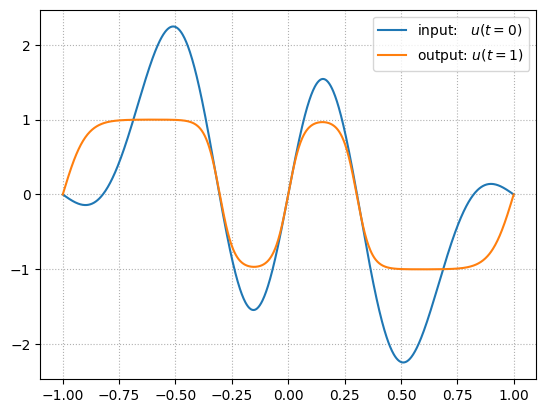

In [188]:
# checking how the data is

id_sample = 46

#plt.plot(np.linspace(-1,1, x_data.shape[1]),x_data[index,:,1])

plt.plot(np.linspace(-1,1,x_data.shape[1]),x_data[id_sample,:,1], label = "input:   $u(t = 0)$")
plt.plot(np.linspace(-1,1,x_data.shape[1]),y_data[id_sample,:], label = "output: $u(t = 1)$")
plt.grid(ls=":")
plt.legend()



In [189]:
n_modes = 15 # number of frequencies required
uplift = 64 # neurons after lifting the dimentions from phy space

In [190]:
class Spectral1d(nn.Module):
    def __init__(self, input_channel, output_channel, n_modes):
        super().__init__()
        self.input_channel = input_channel
        self.output_channel = output_channel
        self.n_modes = n_modes
        scale = 1 / (input_channel * output_channel)
        self.weights = nn.Parameter(scale * torch.rand(input_channel, output_channel, n_modes, dtype=torch.cfloat)) #weights are optimized in training

    def forward(self, x):
        x_ft = torch.fft.rfft(x)  # mapping to fourier space . x.shape[0] = batch size
        out_ft = torch.zeros(x.shape[0], self.output_channel, x.size(-1) // 2 + 1, dtype=torch.cfloat) # zero vector 
        out_ft[:, :, :self.n_modes] = torch.einsum("bix,iox->box", x_ft[:, :, :self.n_modes], self.weights)
        return torch.fft.irfft(out_ft, n=x.size(-1))

In [ ]:
"""class for fourier layer it has two channels, one for spectral space which deals 
   with the derivate form of equation and convutional layer which deals with the physical domain"""


class fourier_layer(nn.Module):
    def __init__(self, uplift, n_modes):
        super().__init__()

        # spectral space
        self.spectral_path = Spectral1d(uplift,uplift,n_modes)
        #phy space, normal convolution
        self.phy_path = nn.Conv1d(uplift,uplift,1) # sigle kernel, similar to matrix mul and tranformation
        self.activation = nn. Tanh()
    
    def forward(self, x):
        return self.activation(self.spectral_path(x)+ self.phy_path(x))


In [192]:
class Model(nn.Module):
    def __init__(self, n_modes, uplift):
        super().__init__()
        self.lifting = nn.Linear(x_train.shape[2], uplift) # step 1 : lifting 2 ---> 64
        self.Fourier = nn.Sequential(
            fourier_layer(uplift, n_modes), # step 2 : fourier transformations
            fourier_layer(uplift, n_modes),  # 3 fourier layers
            fourier_layer(uplift, n_modes),
        )
        #step 3 : projection to physical dimention space
        self.projection = nn.Sequential(
            nn.Linear(uplift,32),
            nn.Linear(32, 1),
            nn.Tanh()
        )

    def forward(self, x):
        output = self.lifting(x)           # (batch, seq_length, uplift)
        output = output.permute(0, 2, 1)   # (batch, uplift, seq_length)
        output = self.Fourier(output)
        output = output.permute(0, 2, 1)   # (batch, seq_length, uplift)
        output = self.projection(output)   # (batch, seq_length, 1)
        return output.squeeze(-1)          # (batch, seq_length)

In [194]:
step_size = 50 # for scheduler
gamma = 0.5

In [195]:
model = Model(n_modes, uplift)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)


In [196]:
# train loop
epochs = 100
for epoch in range(epochs):
    train_mse = 0.0
    for x_train, y_train in train_dataset:
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)
        loss. backward()
        optimizer.step()

        # accumulating loss
        train_mse += loss.item()

    scheduler.step()
    epoch_loss = train_mse/len(train_dataset)
    
    if (epoch + 1) % 10 == 0 :
        print(f"Epoch [{epoch+1:3d}/{epochs}] - Loss: {epoch_loss:.6f}")




Epoch [ 10/100] - Loss: 0.005028
Epoch [ 20/100] - Loss: 0.002117
Epoch [ 30/100] - Loss: 0.001631
Epoch [ 40/100] - Loss: 0.002799
Epoch [ 50/100] - Loss: 0.000481
Epoch [ 60/100] - Loss: 0.000323
Epoch [ 70/100] - Loss: 0.000227
Epoch [ 80/100] - Loss: 0.000203
Epoch [ 90/100] - Loss: 0.000168
Epoch [100/100] - Loss: 0.000143


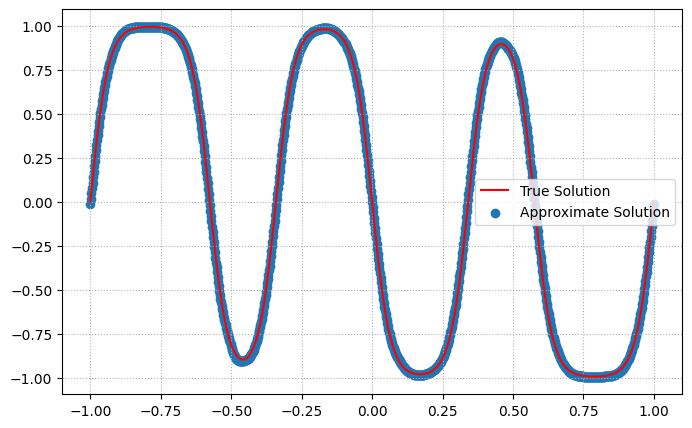

Relative L2 error: 1.6214%


In [198]:
#Select the test sample
idx_data = 121
input_tensor = x_test[idx_data:idx_data+1]  # Keeps the batch dimension
true_output = y_test[idx_data]

# Get the model's prediction
with torch.no_grad():  
    pred_output = model(input_tensor)

# Convert to NumPy for easy plotting
grid_x = np.linspace(-1,1, x_data.shape[1])
y_true = true_output.numpy()
y_pred = pred_output.numpy()

#  Plot the results
plt.figure(figsize=(8, 5))
plt.grid( ls=":")
plt.plot(grid_x, y_true, label="True Solution", color = 'r')
plt.scatter(grid_x, y_pred, label="Approximate Solution" )
plt.legend()
plt.show()

#  Calculate Relative L2 Error
err = (torch.norm(true_output - pred_output) / torch.norm(true_output)) * 100
print(f"Relative L2 error: {err.item():.4f}%")